In [169]:
# ============================================================================
# CELL 1: Imports from existing stable modules (unchanged)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery
from rubin_sim.maf.slicers import UserPointsSlicer
from rubin_sim.phot_utils import DustValues
import astropy.units as u


repo_root = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
sys.path.insert(0, str(repo_root / "py_files"))

# Import from YOUR existing modules (these are NOT modified)

from slsn_metrics.constants import z_from_comoving_fast, dm_from_z
from slsn_metrics.model import LC, CatalogInputs, atomic_save_pickle
from slsn_metrics.metrics import SLSN_Detect_Metric
from slsn_metrics.diagnostics import (
    plot_population_diagnostics,
    characterize_template_coverage
)
from slsn_metrics.runners import (
    run_slsn_detect,
    build_filenames,
    get_distance_bounds
)

# Import the ORIGINAL population function (we'll create a new version)
from slsn_metrics.population import (
    inject_uniform_healpix,
    _cached_uniform_healpix,
    _HEALPIX_MEMO
)

print("✓ Imported all stable modules successfully")

✓ Imported all stable modules successfully


In [171]:
# ============================================================================
# CELL 2: Define NEW rate evolution functions (inline, no module changes)
# ============================================================================

import astropy.units as u

# Observed rate measurements from literature (Figure 1 from abstract)
OBSERVED_RATES = [
    {'z': 0.17, 'rate': 1e-7, 'err_low': 0.3e-7, 'err_high': 0.3e-7, 
     'ref': 'Quimby+13'},
    {'z': 0.3, 'rate': 3.5e-7, 'err_low': 1.0e-7, 'err_high': 1.5e-7, 
     'ref': 'Prajs+17'},
    {'z': 2.0, 'rate': 1.5e-6, 'err_low': 0.5e-6, 'err_high': 0.8e-6, 
     'ref': 'Cooke+12'},
]

def cosmic_sfr_density_MD14(z):
    """
    Madau & Dickinson 2014 cosmic SFR density [M_sun/yr/Mpc^3].
    Equation 15 from their paper.
    """
    z = np.atleast_1d(z)
    psi = 0.015 * (1 + z)**2.7 / (1 + ((1 + z) / 2.9)**5.6)
    # FIX: Use .size instead of len()
    return psi.item() if psi.size == 1 else psi


# ============================================================================
# MZR and Galaxy Population Functions (Equation 2 from abstract)
# ============================================================================

def tremonti04_mzr(log_M_star, z=0):
    """
    Tremonti+2004 Mass-Metallicity Relation (their Equation 3).
    
    12 + log(O/H) as a function of stellar mass.
    
    Parameters
    ----------
    log_M_star : float or array
        log10(M_*/M_sun)
    z : float
        Redshift (Tremonti+04 is z~0; for evolution use Andrews & Martini 2013)
    
    Returns
    -------
    OH : float or array
        12 + log10(O/H) [oxygen abundance]
    
    Notes
    -----
    Tremonti+04 Equation 3:
    12 + log(O/H) = -1.492 + 1.847x - 0.08026x²
    where x = log(M_*/M_sun) - 10
    
    For redshift evolution, we apply Andrews & Martini 2013:
    OH(z) = OH(z=0) - 0.14*z  (approximate)
    """
    log_M_star = np.atleast_1d(log_M_star)
    x = log_M_star - 10.0  # Normalized mass
    
    # Tremonti+04 fit (valid for log M_* ~ 8.5 - 11.5)
    OH_z0 = -1.492 + 1.847*x - 0.08026*x**2
    
    # Redshift evolution (Andrews & Martini 2013)
    # Metallicity decreases with lookback time
    OH = OH_z0 - 0.14 * z
    
    return OH.item() if OH.size == 1 else OH


def leja20_stellar_mass_function(log_M_star, z):
    """
    Leja+2020 stellar mass function Φ(M_*|z).
    
    Simplified Schechter function with redshift evolution.
    
    Parameters
    ----------
    log_M_star : float or array
        log10(M_*/M_sun)
    z : float
        Redshift
    
    Returns
    -------
    phi : float or array
        Number density [Mpc^-3 dex^-1]
    
    Notes
    -----
    This is a SIMPLIFIED version. For full Leja+20 model, see their Table 2.
    Using double Schechter function parameters at z~0.5:
    - φ_1* ≈ 10^-2.5 Mpc^-3 dex^-1
    - M_1* ≈ 10^10.7 M_sun
    - α_1 ≈ -0.4
    """
    log_M_star = np.atleast_1d(log_M_star)
    
    # Redshift-dependent parameters (approximate scaling)
    log_phi_star = -2.5 - 0.3 * z  # Normalization decreases with z
    log_M_star_char = 10.7 - 0.1 * z  # Characteristic mass evolves
    alpha = -0.4 - 0.15 * z  # Faint-end slope steepens
    
    phi_star = 10**log_phi_star
    M_star_char = 10**log_M_star_char
    M_star = 10**log_M_star
    
    # Schechter function: φ(M) = φ* (M/M*)^α exp(-M/M*)
    phi = phi_star * (M_star / M_star_char)**alpha * np.exp(-M_star / M_star_char)
    
    # Convert to per dex: Φ(log M) = ln(10) * M * φ(M)
    phi_per_dex = np.log(10) * M_star * phi
    
    return phi_per_dex.item() if phi_per_dex.size == 1 else phi_per_dex


def leja22_mean_sfr(log_M_star, z):
    """
    Leja+2022 mean SFR as function of stellar mass and redshift.
    
    Star-forming main sequence: SFR ∝ M_* × (1+z)^β
    
    Parameters
    ----------
    log_M_star : float or array
        log10(M_*/M_sun)
    z : float
        Redshift
    
    Returns
    -------
    sfr : float or array
        Mean star formation rate [M_sun/yr]
    
    Notes
    -----
    Simplified main sequence relation:
    log(SFR) = α + β*log(M_*) + γ*log(1+z)
    
    Typical values (Speagle+2014, updated by Leja+22):
    - α ≈ -0.5
    - β ≈ 0.8 (slope of main sequence)
    - γ ≈ 2.5 (redshift evolution)
    """
    log_M_star = np.atleast_1d(log_M_star)
    
    # Main sequence parameters
    alpha = -0.5
    beta = 0.8
    gamma = 2.5
    
    log_sfr = alpha + beta * log_M_star + gamma * np.log10(1 + z)
    sfr = 10**log_sfr
    
    return sfr.item() if sfr.size == 1 else sfr


def metallicity_fraction(z, OH_max=8.3, use_FMR=False):
    """
    Fraction f(z) of star formation in low-metallicity galaxies.
    
    Implements Equation 2 from abstract (MZR version):
    
    f(z) = [∫ Φ(M_*|z) ⟨SFR⟩(M_*|z) Θ{OH[M_*,z] < OH_max} d log M_*] /
           [∫ Φ(M_*|z) ⟨SFR⟩(M_*|z) d log M_*]
    
    Parameters
    ----------
    z : float or array
        Redshift
    OH_max : float
        Metallicity threshold: 12 + log10(O/H)_max
        Default 8.3 (~0.4 Z_solar) from Schulze+21
    use_FMR : bool
        Not implemented (would use Eq 1 with Sanders+21)
    
    Returns
    -------
    f : float or array
        Fraction of SF in galaxies below metallicity threshold
    """
    z = np.atleast_1d(z)
    f_z = np.zeros_like(z, dtype=float)
    
    # Integration limits for stellar mass
    # Range: 10^8 M_sun to 10^12 M_sun (dwarf galaxies to massive ellipticals)
    log_M_min = 8.0
    log_M_max = 12.0
    n_mass_bins = 200
    
    log_M_grid = np.linspace(log_M_min, log_M_max, n_mass_bins)
    d_log_M = log_M_grid[1] - log_M_grid[0]
    
    for i, z_val in enumerate(z):
        # Calculate integrand at each mass
        phi = leja20_stellar_mass_function(log_M_grid, z_val)  # [Mpc^-3 dex^-1]
        sfr = leja22_mean_sfr(log_M_grid, z_val)               # [M_sun/yr]
        OH = tremonti04_mzr(log_M_grid, z_val)                 # [12 + log(O/H)]
        
        # Heaviside function: Θ(OH_max - OH)
        # = 1 if OH < OH_max (low metallicity)
        # = 0 if OH >= OH_max (high metallicity)
        low_metallicity_mask = (OH < OH_max)
        
        # Numerator: SF in low-metallicity galaxies
        integrand_lowZ = phi * sfr * low_metallicity_mask.astype(float)
        numerator = np.trapz(integrand_lowZ, dx=d_log_M)
        
        # Denominator: Total SF
        integrand_total = phi * sfr
        denominator = np.trapz(integrand_total, dx=d_log_M)
        
        # Fraction
        f_z[i] = numerator / denominator if denominator > 0 else 0.0
    
    return f_z.item() if f_z.size == 1 else f_z


print("✓ Defined MZR-based metallicity_fraction() with proper physics")


def slsn_rate_evolution(z, R_ref=1e-7, z_ref=0.17, OH_max=8.3):
    """
    Redshift-dependent SLSN volumetric rate [Mpc^-3 yr^-1].
    
    Implements Equation 3 from abstract:
    R(z) = R(z_ref) × [Ψ(z) × f(z)] / [Ψ(z_ref) × f(z_ref)]
    
    Parameters
    ----------
    z : float or array
        Redshift
    R_ref : float
        Reference rate at z_ref (default: 1e-7 from Quimby+13)
    z_ref : float
        Reference redshift (default: 0.17 from Quimby+13)
    OH_max : float
        Metallicity threshold (default: 8.3 from Schulze+21)
    
    Returns
    -------
    rate : float or array
        Volumetric SLSN rate [Mpc^-3 yr^-1]
    """
    z = np.atleast_1d(z)
    
    # Cosmic SFR densities
    psi_z = cosmic_sfr_density_MD14(z)
    psi_ref = cosmic_sfr_density_MD14(z_ref)
    
    # Metallicity fractions
    f_z = metallicity_fraction(z, OH_max)
    f_ref = metallicity_fraction(z_ref, OH_max)
    
    rate = np.atleast_1d(R_ref * (psi_z * f_z) / (psi_ref * f_ref))
    
    return rate.item() if rate.size == 1 else rate


def sample_events_from_evolving_rate(R_ref, z_ref, z_min, z_max, 
                                      t_start, t_end, OH_max, n_bins=100):
    """
    Calculate expected number of events from redshift-dependent rate.
    
    Integrates: N = ∫ R(z) × dV/dz × dz × Δt
    """
    years = (t_end - t_start) / 365.25
    
    # Integrate over redshift shells
    z_grid = np.linspace(z_min, z_max, n_bins)
    dz = z_grid[1] - z_grid[0]
    
    total_rate = 0.0
    for z in z_grid:
        R_z = slsn_rate_evolution(z, R_ref, z_ref, OH_max)
        # Full solid angle: 4π steradians
        dV_dz = cosmo.differential_comoving_volume(z).to_value(u.Mpc**3 / u.sr) * 4 * np.pi
        total_rate += R_z * dV_dz * dz
    
    expected_n = total_rate * years
    
    print(f"Expected events from R(z) integration: {expected_n:.1f}")
    print(f"  [z_min={z_min}, z_max={z_max}, t={years:.1f} yr]")
    
    return int(np.random.poisson(expected_n))


def sample_redshifts_weighted_by_rate(n_events, z_min, z_max, 
                                       R_ref, z_ref, OH_max, n_bins=1000):
    """
    Sample redshifts from probability distribution P(z) ∝ R(z) × dV/dz.
    
    Uses inverse transform sampling (importance sampling).
    """
    import astropy.units as u
    # Build CDF
    z_grid = np.linspace(z_min, z_max, n_bins)
    
    weights = np.array([
        slsn_rate_evolution(z, R_ref, z_ref, OH_max) * 
        cosmo.differential_comoving_volume(z).to_value(u.Mpc**3 / u.sr)
        for z in z_grid
    ])
    
    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]  # Normalize
    
    # Inverse transform sampling
    u = np.random.uniform(0, 1, n_events)
    z_samples = np.interp(u, cdf, z_grid)
    
    return z_samples


print("✓ Defined all rate evolution functions")

✓ Defined MZR-based metallicity_fraction() with proper physics
✓ Defined all rate evolution functions


In [173]:
# ============================================================================
# CELL 3: Create NEW population generator (wrapper around stable functions)
# ============================================================================

def generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model, 
    t_start=1, 
    t_end=3652,
    z_min=0.1, 
    z_max=2.0,
    rate_model='evolving',      # 'evolving' or 'constant'
    rate_density=1e-7,          # Only used if rate_model='constant'
    R_ref=1e-7,                 # Reference rate for evolving model
    z_ref=0.17,                 # Reference redshift (Quimby+13)
    OH_max=8.3,                 # Metallicity threshold (Schulze+21)
    peak_t_min=None, 
    peak_t_max=None,
    gal_lat_cut=None,
    seed=42,
    healpix_cache_file=None,
    save_to=None,
    load_from=None,
    make_debug_plots=True
):
    """
    Generate SLSN population with optional rate evolution R(z).
    
    This is a WRAPPER that adds rate evolution on top of the stable
    population generation logic.
    
    NEW Parameters
    --------------
    rate_model : str
        'evolving' = use R(z) from abstract (metallicity-dependent)
        'constant' = use fixed rate_density (original behavior)
    R_ref : float
        Reference volumetric rate at z_ref [Mpc^-3 yr^-1]
    z_ref : float
        Reference redshift for rate normalization
    OH_max : float
        Metallicity threshold: 12 + log10(O/H)_max
    
    All other parameters same as original generate_SLSN_PopSlicer.
    """
    
    # Fast reload path (unchanged)
    if load_from and Path(load_from).exists():
        with open(load_from, 'rb') as f:
            slice_data = pickle.load(f)
        slicer = UserPointsSlicer(ra=slice_data['ra'], dec=slice_data['dec'], badval=0)
        slicer.slice_points.update(slice_data)
        n_loaded = len(slice_data['ra'])
        print(f"[LOAD] Loaded {n_loaded} SLSNe from {load_from}")
        return slicer
    
    # Check template coverage (unchanged logic from population.py)
    valid_templates = []
    for i, sed in enumerate(lc_model.sed_grid):
        lam_min = sed['lam_rest_A'].min()
        lam_max = sed['lam_rest_A'].max()
        lam_range = lam_max - lam_min
        if lam_range > 2000:
            valid_templates.append(i)
    
    print(f"Valid templates: {len(valid_templates)}/{len(lc_model.sed_grid)}")
    if len(valid_templates) == 0:
        raise RuntimeError("No valid templates with sufficient wavelength coverage!")
    
    rng = np.random.default_rng(seed)
    
    # ========== KEY DIFFERENCE: Rate-dependent sampling ==========
    if rate_model == 'evolving':
        print(f"\n{'='*70}")
        print(f"USING RATE EVOLUTION MODEL")
        print(f"{'='*70}")
        print(f"Reference: R({z_ref}) = {R_ref:.2e} Mpc^-3 yr^-1")
        print(f"Metallicity threshold: 12+log(O/H) < {OH_max}")
        
        # Sample event count from integrated R(z)
        n_events = sample_events_from_evolving_rate(
            R_ref, z_ref, z_min, z_max, t_start, t_end, OH_max
        )
        
        # Sample redshifts weighted by R(z) × dV/dz
        z_vals_raw = sample_redshifts_weighted_by_rate(
            n_events, z_min, z_max, R_ref, z_ref, OH_max
        )
        
        print(f"Generated {n_events} events")
        print(f"Redshift range: {z_vals_raw.min():.3f} - {z_vals_raw.max():.3f}")
        print(f"Mean redshift: {z_vals_raw.mean():.3f}")
        print(f"{'='*70}\n")
        
    else:  # 'constant' - original behavior
        print(f"\n{'='*70}")
        print(f"USING CONSTANT RATE MODEL")
        print(f"{'='*70}")
        print(f"Rate density: {rate_density:.2e} Mpc^-3 yr^-1 (flat across all z)")
        
        # Original uniform comoving volume sampling
        from slsn_metrics.population import sample_rate_from_volume
        n_events = sample_rate_from_volume(
            rate_density, t_start, t_end, z_min=z_min, z_max=z_max
        )
        
        z_min_mpc = cosmo.comoving_distance(z_min).to_value(u.Mpc)
        z_max_mpc = cosmo.comoving_distance(z_max).to_value(u.Mpc)
        u_rand = rng.uniform(0.0, 1.0, n_events)
        d_mpc = ((z_max_mpc**3 - z_min_mpc**3) * u_rand + z_min_mpc**3)**(1.0/3.0)
        z_vals_raw = z_from_comoving_fast(d_mpc)
        
        print(f"Generated {n_events} events")
        print(f"{'='*70}\n")
    
    # ========== Everything below is UNCHANGED from original ==========
    
    # Generate sky positions (reuses stable function)
    nside = 64
    ra, dec = _cached_uniform_healpix(nside, n_events, seed, 
                                      cache_file=healpix_cache_file)
    
    # Convert to SkyCoord and apply galactic cut
    coords = SkyCoord(ra * u.deg, dec * u.deg, frame='icrs')
    
    if gal_lat_cut is not None:
        galb_before = coords.galactic.b.deg
        mask = np.abs(galb_before) > gal_lat_cut
        
        n_before = len(ra)
        ra = ra[mask]
        dec = dec[mask]
        coords = coords[mask]
        z_vals_raw = z_vals_raw[mask]  # Also filter redshifts!
        n_after = len(ra)
        
        print(f"[GAL LAT CUT] Applied |b| > {gal_lat_cut}° cut:")
        print(f"  Before: {n_before} events")
        print(f"  After:  {n_after} events ({100*n_after/n_before:.1f}% retained)")
        
        n_events = n_after
    
    z_vals = z_vals_raw
    distances = cosmo.comoving_distance(z_vals).to_value(u.Mpc)
    
    # Random template per event
    file_indx = rng.choice(valid_templates, size=n_events)
    
    # Peak times
    peak_t_min = t_start if peak_t_min is None else peak_t_min
    peak_t_max = t_end if peak_t_max is None else peak_t_max
    peak_times = rng.uniform(peak_t_min, peak_t_max, n_events)
    
    # Query EBV
    sfd = SFDQuery()
    ebv_vals = sfd(coords)
    
    # Build slicer
    slicer = UserPointsSlicer(ra=ra, dec=dec, badval=0)
    sp = slicer.slice_points
    
    # Core properties
    sp['sid'] = np.arange(n_events)
    sp['z'] = z_vals
    sp['distance'] = distances
    sp['distance_modulus'] = dm_from_z(z_vals)
    sp['peak_time'] = peak_times
    sp['file_indx'] = file_indx
    sp['ebv'] = ebv_vals
    sp['gall'] = coords.galactic.l.deg
    sp['galb'] = coords.galactic.b.deg
    
    # Store rate model metadata
    sp['rate_model'] = rate_model
    if rate_model == 'evolving':
        sp['R_ref'] = R_ref
        sp['z_ref'] = z_ref
        sp['OH_max'] = OH_max
    
    # Per-filter extinctions
    dust_model = DustValues()
    ax1 = dust_model.ax1
    for f in ['u', 'g', 'r', 'i', 'z', 'y']:
        sp[f'A_{f}'] = ax1[f] * ebv_vals
    
    # Peak magnitude summaries
    for f in ['u', 'g', 'r', 'i', 'z', 'y']:
        peak_abs, peak_noebv, peak_ebv = [], [], []
        for idx, z_val, dm, ebv in zip(file_indx, z_vals, 
                                        sp['distance_modulus'], ebv_vals):
            if (f in lc_model.data[idx] and 
                len(lc_model.data[idx][f]['mag']) > 0):
                M_abs = float(np.min(lc_model.data[idx][f]['mag']))
            else:
                M_abs = np.nan
            m_noebv = M_abs + dm
            m_ebv = m_noebv + ax1[f] * ebv
            peak_abs.append(M_abs)
            peak_noebv.append(m_noebv)
            peak_ebv.append(m_ebv)
        sp[f'peak_mag_abs_{f}'] = np.array(peak_abs)
        sp[f'peak_app_mag_noebv_{f}'] = np.array(peak_noebv)
        sp[f'peak_app_mag_ebv_{f}'] = np.array(peak_ebv)
    
    # Diagnostic plots
    if make_debug_plots:
        plot_population_diagnostics(
            ra_rad=sp['ra'],
            dec_rad=sp['dec'],
            peak_times=sp['peak_time'],
            distances_mpc=sp['distance'],
            z_vals=sp['z'],
            ebv=sp.get('ebv', None),
            gall=sp.get('gall', None),
            galb=sp.get('galb', None),
            outdir=Path(save_to).parent if save_to else None,
            prefix=f"population_{rate_model}"
        )
    
    # Save
    if save_to:
        atomic_save_pickle(dict(sp), save_to)
        print(f"Saved SLSN population to {save_to}")
    
    return slicer

print("✓ Created new population generator with rate evolution")

✓ Created new population generator with rate evolution


In [175]:
# ============================================================================
# CELL 4: Analysis and plotting functions
# ============================================================================

def plot_rate_evolution_comparison(z_grid=None, OH_max=8.3, 
                                    R_ref=1e-7, z_ref=0.17,
                                    save_path=None):
    """
    Reproduce Figure 1 from abstract: rate evolution with/without metallicity.
    """
    if z_grid is None:
        z_grid = np.linspace(0.0, 3.0, 100)
    
    # Calculate rate with metallicity evolution
    rate_with_metallicity = slsn_rate_evolution(z_grid, R_ref, z_ref, OH_max)
    
    # Calculate rate WITHOUT metallicity (f(z) = constant)
    psi_z = cosmic_sfr_density_MD14(z_grid)
    psi_ref = cosmic_sfr_density_MD14(z_ref)
    rate_no_metallicity = R_ref * psi_z / psi_ref
    
    # Metallicity fraction f(z)
    f_z = metallicity_fraction(z_grid, OH_max)
    
    # Create figure
    fig, (ax_frac, ax_rate) = plt.subplots(2, 1, figsize=(8, 10), 
                                             sharex=True)
    
    # Top panel: f(z)
    ax_frac.plot(z_grid, f_z, 'r-', lw=2.5, 
                 label=f'$f(z)$ [OH_max = {OH_max}]')
    ax_frac.set_ylabel('Fraction $f(z)$', fontsize=13)
    ax_frac.set_ylim(0, 1)
    ax_frac.legend(fontsize=11)
    ax_frac.grid(alpha=0.3)
    ax_frac.set_title('Fraction of SF in Low-Metallicity Galaxies', fontsize=14)
    
    # Bottom panel: Rate evolution
    ax_rate.plot(z_grid, rate_with_metallicity, 'r-', lw=2.5,
                 label='With metallicity evolution')
    ax_rate.plot(z_grid, rate_no_metallicity, 'b--', lw=2.5,
                 label='No metallicity (pure CSFRD)')
    
    # Observed data points
    for i, obs in enumerate(OBSERVED_RATES):
        label = obs['ref'] if i == 0 else None
        ax_rate.errorbar(obs['z'], obs['rate'], 
                         yerr=[[obs['err_low']], [obs['err_high']]],
                         fmt='ko', markersize=8, capsize=5, capthick=2,
                         label='Observed' if i == 0 else None)
    
    ax_rate.set_xlabel('Redshift $z$', fontsize=13)
    ax_rate.set_ylabel('Volumetric Rate [Mpc$^{-3}$ yr$^{-1}$]', fontsize=13)
    ax_rate.set_yscale('log')
    ax_rate.set_ylim(1e-8, 1e-5)
    ax_rate.legend(fontsize=11)
    ax_rate.grid(alpha=0.3, which='both')
    ax_rate.set_title('SLSN Volumetric Rate Evolution', fontsize=14)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()
    return fig


def compare_simulated_vs_observed_rates(population_slicer, z_bins=None):
    """
    Compare simulated event rate to observed literature rates.
    """
    if z_bins is None:
        z_bins = np.array([0.0, 0.3, 0.6, 1.0, 1.5, 2.5])
    
    sp = population_slicer.slice_points
    z_vals = sp['z']
    peak_times = sp['peak_time']
    
    # Survey duration
    t_survey_years = (peak_times.max() - peak_times.min()) / 365.25
    
    results = []
    
    for i in range(len(z_bins) - 1):
        z_low, z_high = z_bins[i], z_bins[i+1]
        z_mid = 0.5 * (z_low + z_high)
        
        # Events in this bin
        mask = (z_vals >= z_low) & (z_vals < z_high)
        n_events = mask.sum()
        
        # Comoving volume
        V_low = cosmo.comoving_volume(z_low).to_value(u.Mpc**3)
        V_high = cosmo.comoving_volume(z_high).to_value(u.Mpc**3)
        V_shell = V_high - V_low
        
        # Simulated rate
        rate_sim = n_events / (V_shell * t_survey_years) if V_shell > 0 else 0
        
        # Corresponding observed rate
        obs_match = [obs for obs in OBSERVED_RATES 
                     if z_low <= obs['z'] < z_high]
        if obs_match:
            rate_obs = obs_match[0]['rate']
            ref = obs_match[0]['ref']
        else:
            rate_obs = np.nan
            ref = '—'
        
        results.append({
            'z_min': z_low,
            'z_max': z_high,
            'z_mid': z_mid,
            'n_events': n_events,
            'volume_Mpc3': V_shell,
            'rate_simulated': rate_sim,
            'rate_observed': rate_obs,
            'ratio_sim/obs': rate_sim / rate_obs if np.isfinite(rate_obs) else np.nan,
            'reference': ref
        })
    
    df = pd.DataFrame(results)
    
    print("\n" + "="*85)
    print("SIMULATED VS OBSERVED RATE COMPARISON")
    print("="*85)
    print(df.to_string(index=False, float_format=lambda x: f'{x:.2e}'))
    print("="*85 + "\n")
    
    return df


def plot_population_rate_vs_redshift(population_slicer, 
                                       rate_model='evolving',
                                       R_ref=1e-7, z_ref=0.17, OH_max=8.3,
                                       z_bins=None, save_path=None):
    """
    Diagnostic plot: simulated event rate vs redshift compared to theory.
    """
    sp = population_slicer.slice_points
    z_vals = sp['z']
    peak_times = sp['peak_time']
    t_survey_years = (peak_times.max() - peak_times.min()) / 365.25
    
    if z_bins is None:
        z_bins = np.linspace(z_vals.min(), z_vals.max(), 15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram of simulated events
    counts, edges = np.histogram(z_vals, bins=z_bins)
    z_centers = 0.5 * (edges[:-1] + edges[1:])
    
    # Convert to volumetric rate
    rates_sim = []
    for i in range(len(edges)-1):
        V = (cosmo.comoving_volume(edges[i+1]).to_value(u.Mpc**3) - 
             cosmo.comoving_volume(edges[i]).to_value(u.Mpc**3))
        rate = counts[i] / (V * t_survey_years)
        rates_sim.append(rate)
    
    ax.scatter(z_centers, rates_sim, s=100, alpha=0.7, 
               label='Simulated', edgecolors='k', linewidths=1.5, zorder=3,
               c='steelblue')
    
    # Theoretical curve
    if rate_model == 'evolving':
        z_theory = np.linspace(z_vals.min(), z_vals.max(), 100)
        rate_theory = slsn_rate_evolution(z_theory, R_ref, z_ref, OH_max)
        ax.plot(z_theory, rate_theory, 'r-', lw=2.5, 
                label=f'Theory: R(z) [OH_max={OH_max}]', zorder=2)
    
    # Observed points
    for i, obs in enumerate(OBSERVED_RATES):
        if z_vals.min() <= obs['z'] <= z_vals.max():
            label = 'Observed' if i == 0 else None
            ax.errorbar(obs['z'], obs['rate'],
                        yerr=[[obs['err_low']], [obs['err_high']]],
                        fmt='ko', markersize=10, capsize=5, capthick=2,
                        label=label, zorder=4)
    
    ax.set_xlabel('Redshift', fontsize=13)
    ax.set_ylabel('Volumetric Rate [Mpc$^{-3}$ yr$^{-1}$]', fontsize=13)
    ax.set_yscale('log')
    ax.set_title(f'Simulated SLSN Rate vs Redshift ({rate_model} model)', 
                 fontsize=14)
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.3, which='both')
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()
    return fig

print("✓ Defined all analysis functions")

✓ Defined all analysis functions


In [177]:
# ============================================================================
# CELL 5: Load existing templates (unchanged workflow)
# ============================================================================

# You can load your existing templates - no need to rebuild!
templates_file = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates.pkl")
mag_grid_file = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates_mag_grid.pkl")

templates = LC(load_from=templates_file)
templates.load_magnitude_grid(mag_grid_file)

print(f"✓ Loaded {len(templates.names)} templates")
print(f"✓ Loaded mag_grid with filters: {list(templates.mag_grid.keys())}")

[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y']
✓ Loaded 261 templates
✓ Loaded mag_grid with filters: ['u', 'g', 'r', 'i', 'z', 'y']


/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


✓ Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_theory_prediction.png


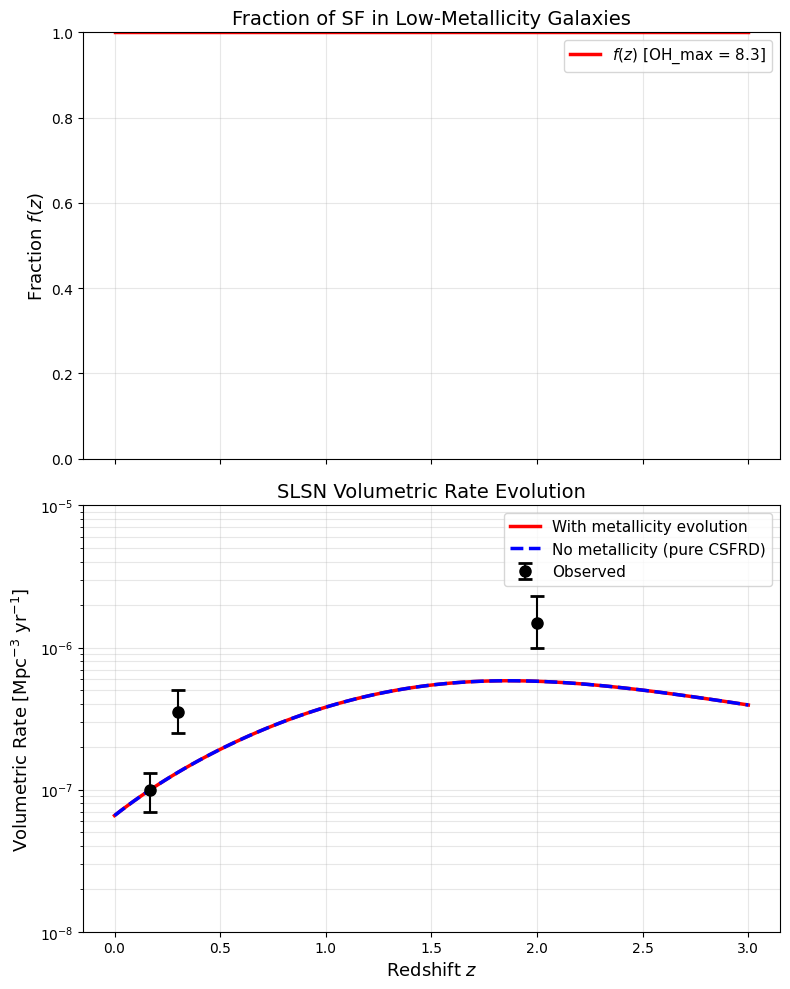

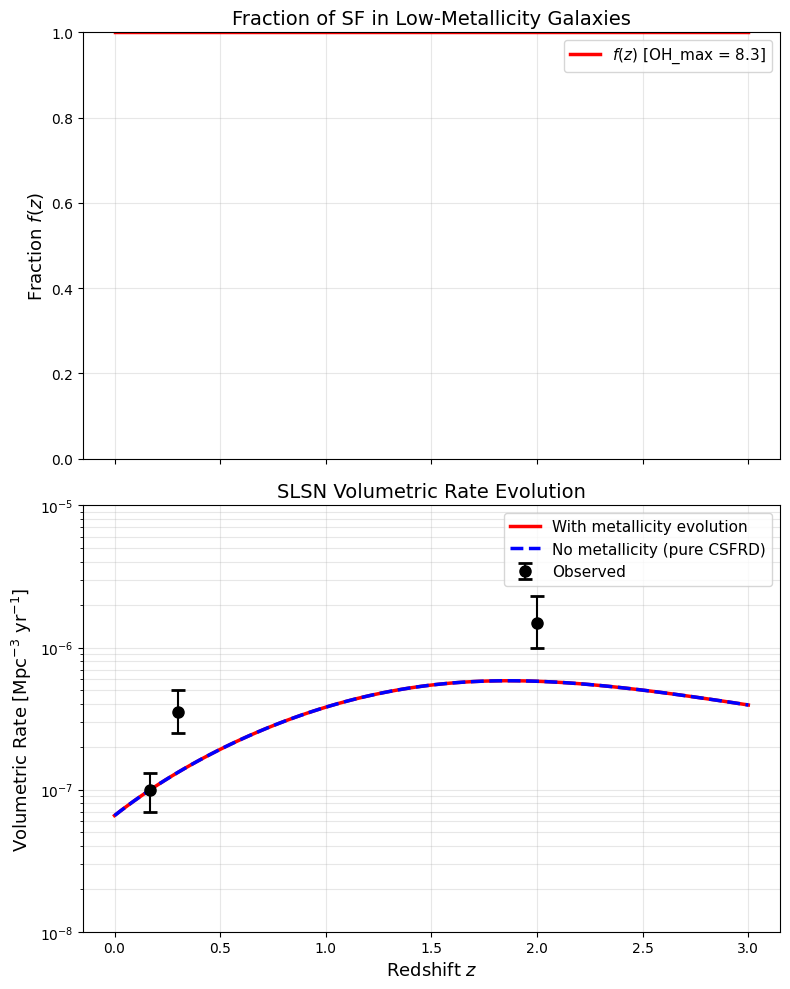

In [179]:
# ============================================================================
# CELL 6: Plot theoretical rate evolution (before generating population)
# ============================================================================

# This shows what the abstract predicts
plot_rate_evolution_comparison(
    OH_max=8.3,
    R_ref=1e-7,
    z_ref=0.17,
    save_path="/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_theory_prediction.png"
)

Valid templates: 165/261

USING RATE EVOLUTION MODEL
Reference: R(0.17) = 1.00e-07 Mpc^-3 yr^-1
Metallicity threshold: 12+log(O/H) < 8.3
Expected events from R(z) integration: 2910132.1
  [z_min=0.1, z_max=2.0, t=10.0 yr]
Generated 2911118 events
Redshift range: 0.100 - 2.000
Mean redshift: 1.437



/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


[GAL LAT CUT] Applied |b| > 15.0° cut:
  Before: 2911118 events
  After:  2156992 events (74.1% retained)


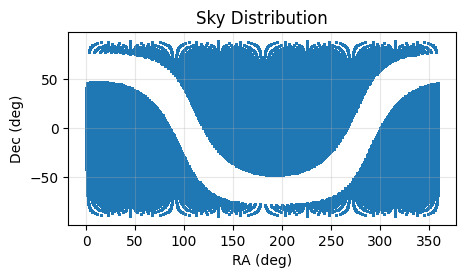

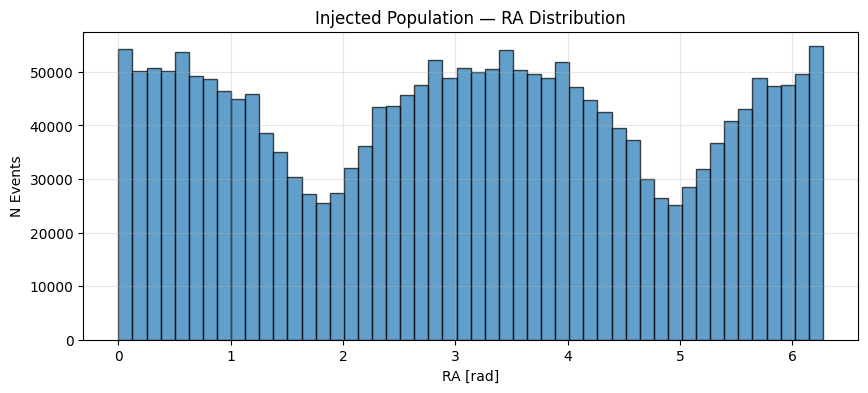

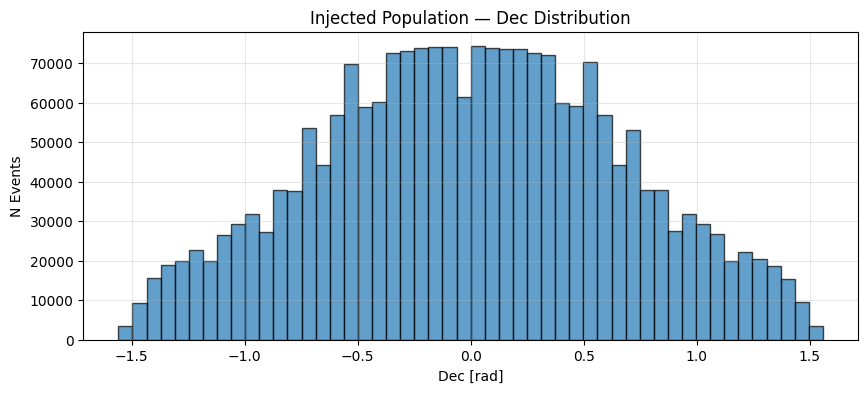

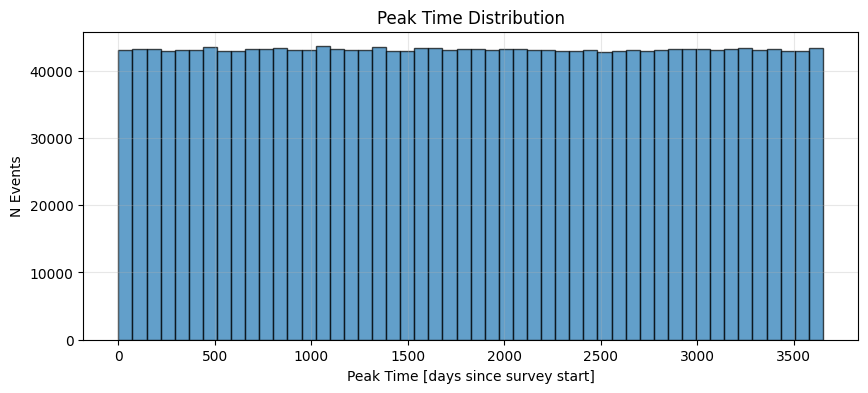

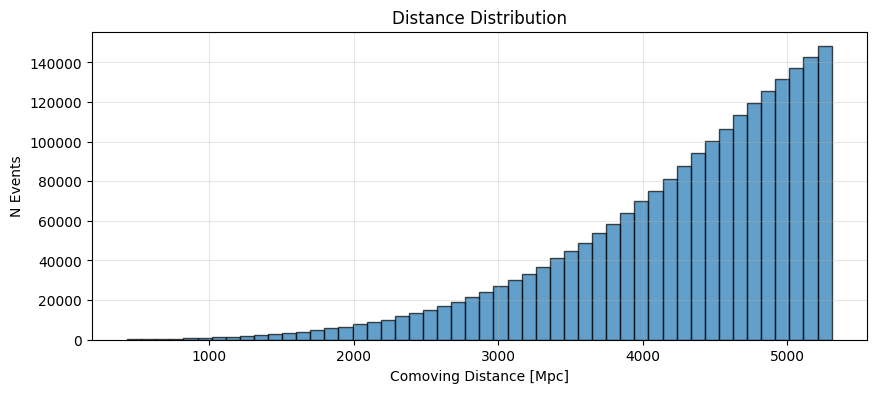

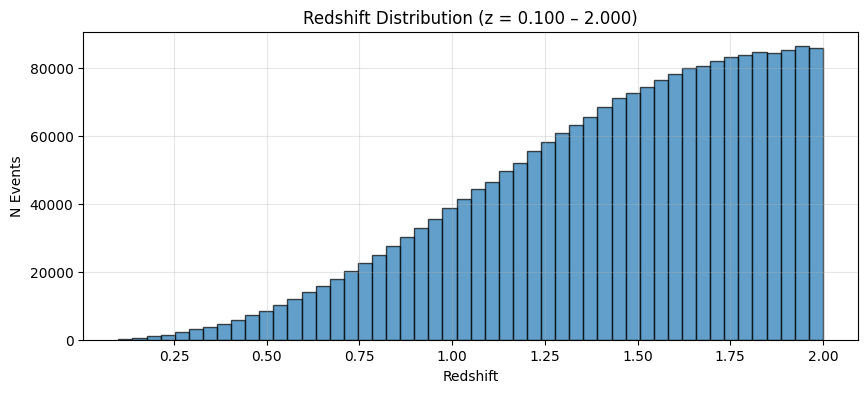

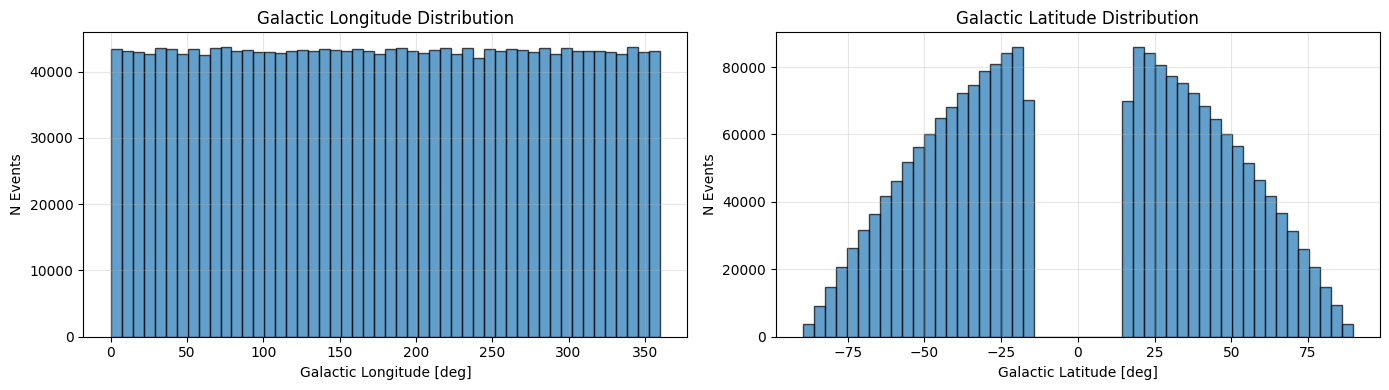

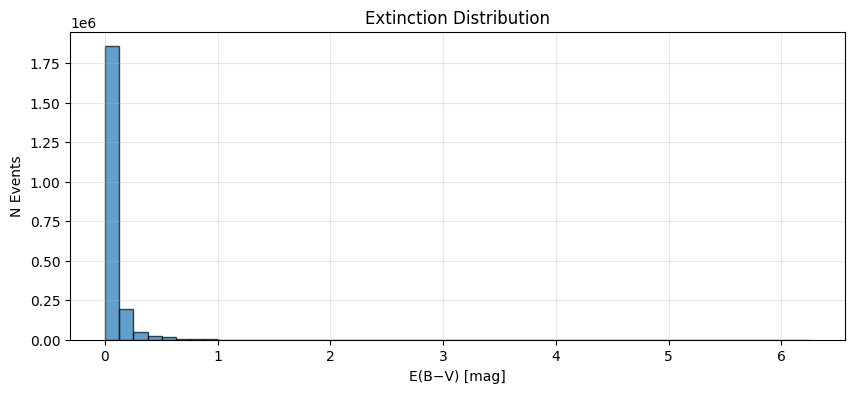

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl

✓ Generated 2156992 SLSNe


In [181]:
# ============================================================================
# CELL 7: Generate population WITH rate evolution
# ============================================================================

pop_evolving = generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model=templates,
    rate_model='evolving',      # KEY: Use rate evolution!
    R_ref=1e-7,                  # Quimby+13 @ z=0.17
    z_ref=0.17,
    OH_max=8.3,                  # Schulze+21 threshold
    z_min=0.1,
    z_max=2.0,
    t_start=1,
    t_end=3652,
    gal_lat_cut=15.0,            # Optional: avoid Galactic plane
    seed=42,
    save_to=Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl"),
    make_debug_plots=True
)

print(f"\n✓ Generated {len(pop_evolving.slice_points['sid'])} SLSNe")

Valid templates: 165/261

USING CONSTANT RATE MODEL
Rate density: 1.00e-07 Mpc^-3 yr^-1 (flat across all z)
[INFO] z_min = 0.10000 -> d_min = 432.565697738352355 Mpc
[INFO] z_max = 2.00000 -> d_max = 5308.188883886385156 Mpc
Generated 626990 events

[GAL LAT CUT] Applied |b| > 15.0° cut:
  Before: 626990 events
  After:  464287 events (74.1% retained)


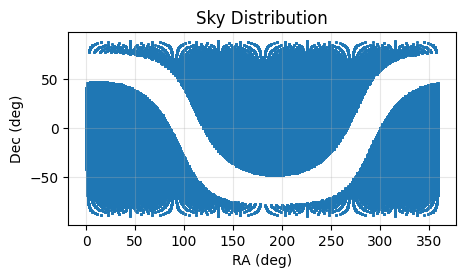

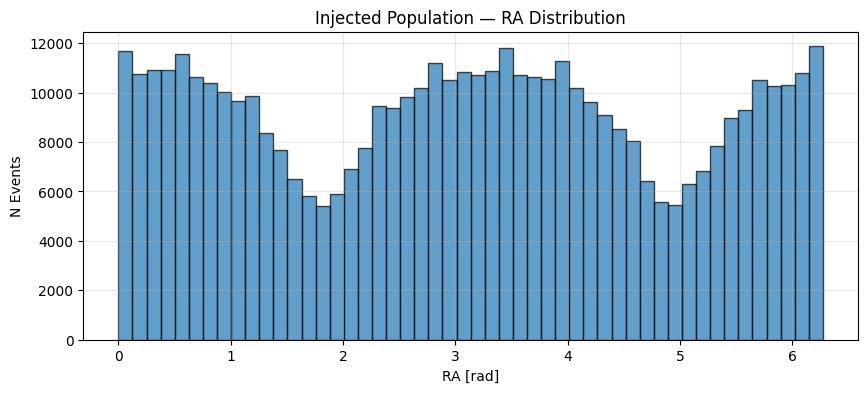

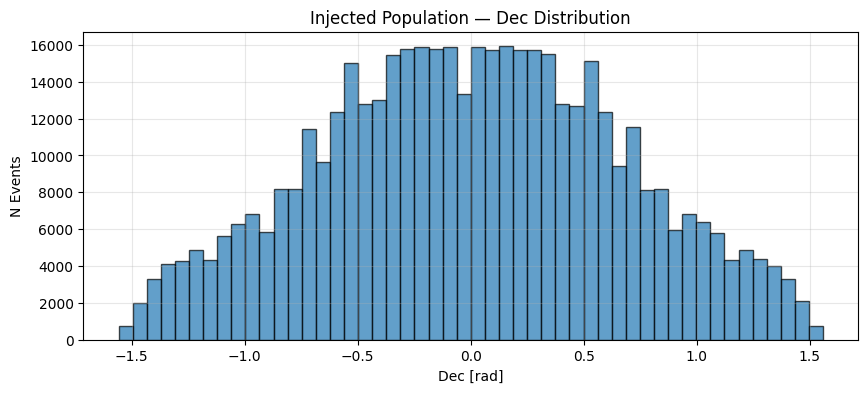

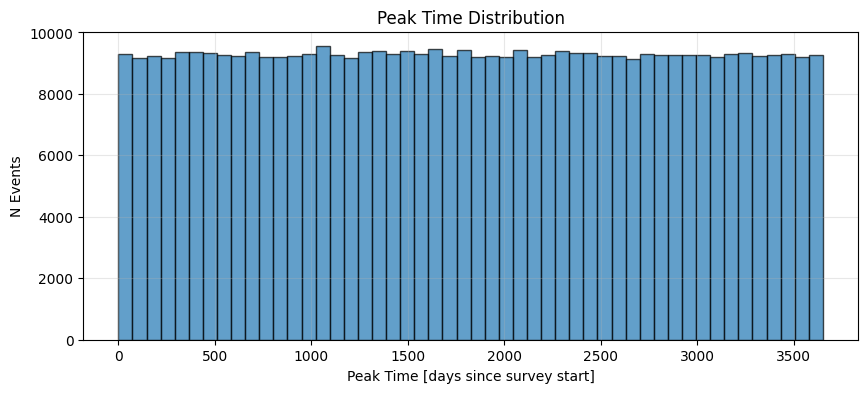

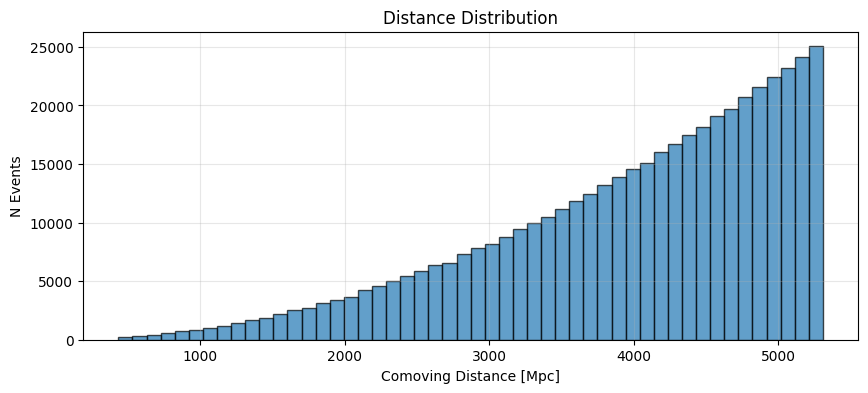

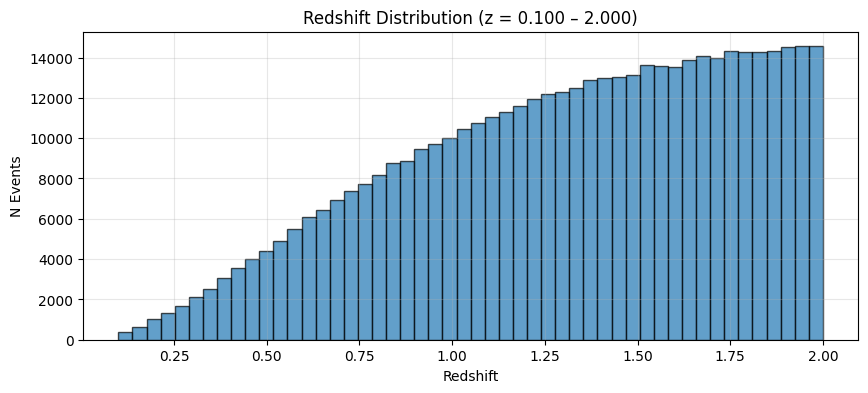

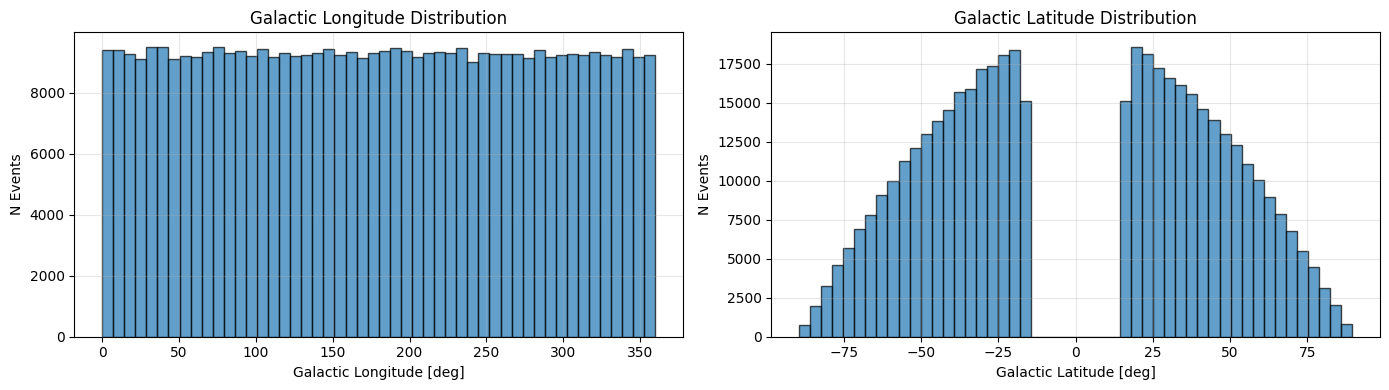

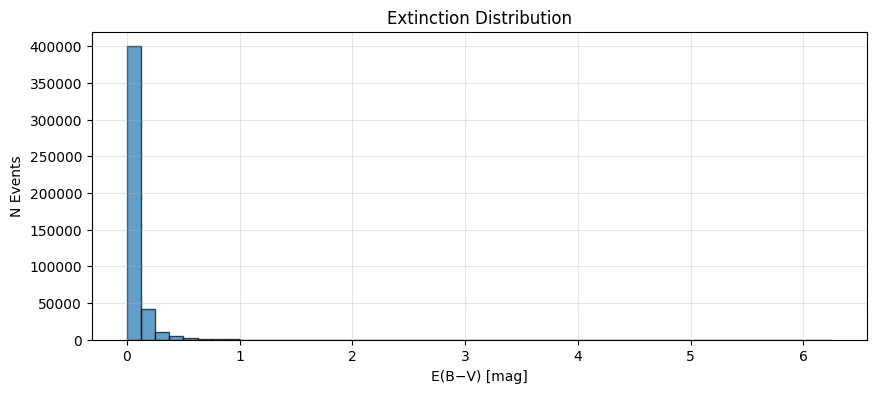

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_constant.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_constant.pkl

✓ Generated 464287 SLSNe


In [182]:
# ============================================================================
# CELL 8: Generate population WITHOUT rate evolution (for comparison)
# ============================================================================

pop_constant = generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model=templates,
    rate_model='constant',       # OLD: Constant rate
    rate_density=1e-7,
    z_min=0.1,
    z_max=2.0,
    t_start=1,
    t_end=3652,
    gal_lat_cut=15.0,
    seed=42,
    save_to=Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_constant.pkl"),
    make_debug_plots=True
)

print(f"\n✓ Generated {len(pop_constant.slice_points['sid'])} SLSNe")

In [185]:
# ============================================================================
# CELL 9: Compare simulated vs observed rates
# ============================================================================

print("="*80)
print("EVOLVING RATE MODEL")
print("="*80)
df_evolving = compare_simulated_vs_observed_rates(pop_evolving)

print("\n" + "="*80)
print("CONSTANT RATE MODEL")
print("="*80)
df_constant = compare_simulated_vs_observed_rates(pop_constant)

EVOLVING RATE MODEL

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
0.00e+00 3.00e-01 1.50e-01      6441     7.85e+09        8.21e-08       1.00e-07       8.21e-01 Quimby+13
3.00e-01 6.00e-01 4.50e-01     57003     4.13e+10        1.38e-07       3.50e-07       3.94e-01  Prajs+17
6.00e-01 1.00e+00 8.00e-01    265585     1.15e+11        2.31e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    750687     2.12e+11        3.54e-07            NaN            NaN         —
1.50e+00 2.50e+00 2.00e+00   1077276     5.14e+11        2.10e-07       1.50e-06       1.40e-01  Cooke+12


CONSTANT RATE MODEL

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
0.00e+00 3.00e-01 1.50e-01      5545     7.85e+09        7.07e-08       1.00e-07       7.07e-01 Quimby+13
3.00e-01 6.00e-01 4.50e-01     3

✓ Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_evolving.png


/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


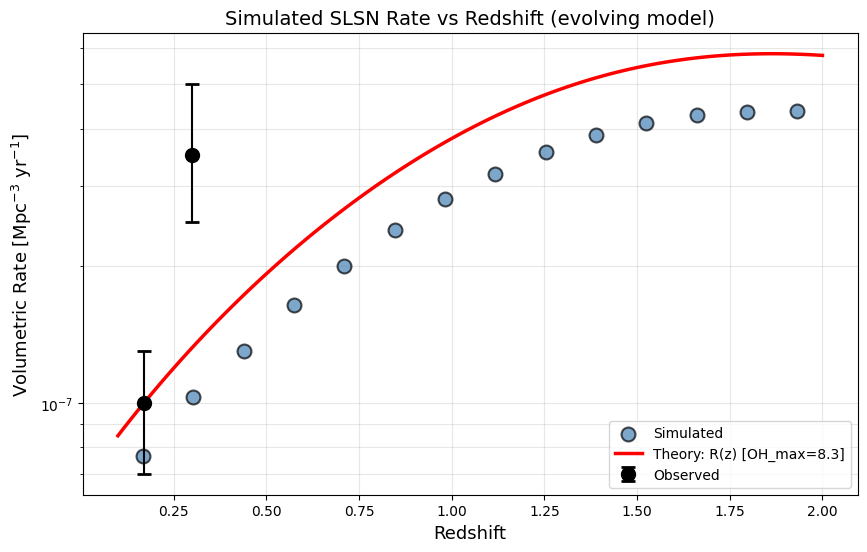

✓ Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_constant.png


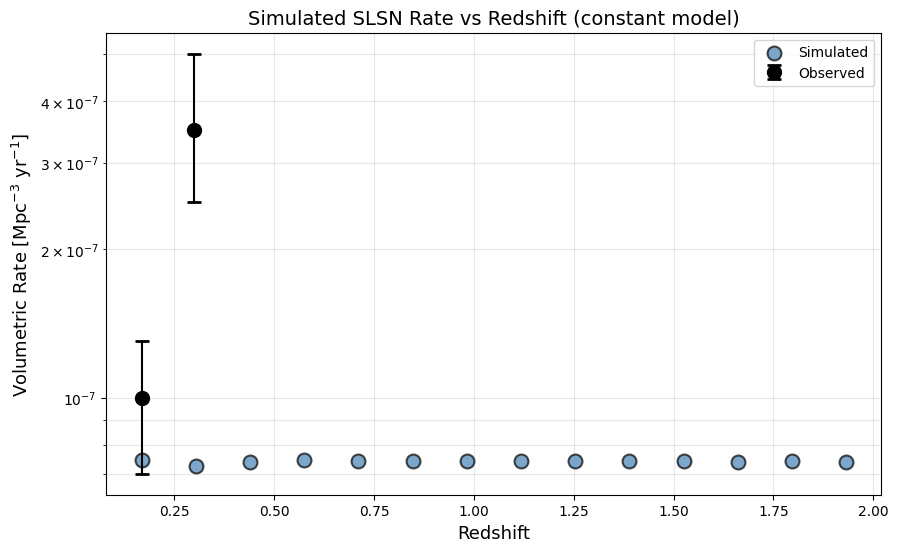

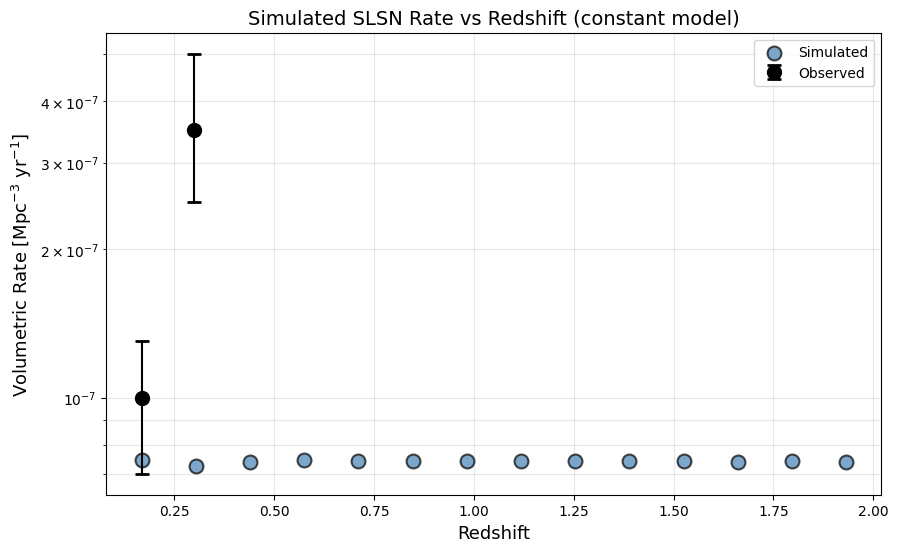

In [187]:
# ============================================================================
# CELL 10: Diagnostic plots
# ============================================================================

# Plot simulated vs theory
plot_population_rate_vs_redshift(
    pop_evolving,
    rate_model='evolving',
    R_ref=1e-7,
    z_ref=0.17,
    OH_max=8.3,
    save_path="/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_evolving.png"
)

plot_population_rate_vs_redshift(
    pop_constant,
    rate_model='constant',
    save_path="/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_constant.png"
)

Valid templates: 165/261

USING RATE EVOLUTION MODEL
Reference: R(0.17) = 1.00e-07 Mpc^-3 yr^-1
Metallicity threshold: 12+log(O/H) < 8.3
Expected events from R(z) integration: 290136.4
  [z_min=0.1, z_max=2.0, t=1.0 yr]
Generated 290247 events
Redshift range: 0.100 - 2.000
Mean redshift: 1.437

[GAL LAT CUT] Applied |b| > 15.0° cut:
  Before: 290247 events
  After:  214954 events (74.1% retained)


/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_15876/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


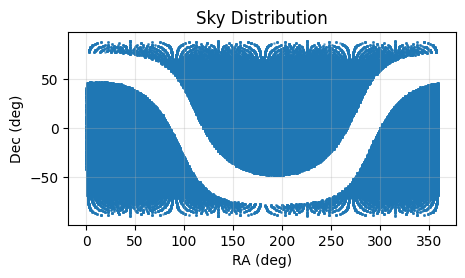

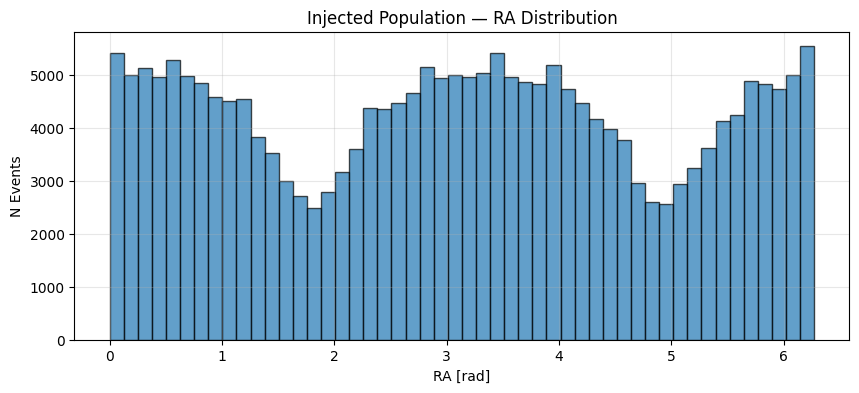

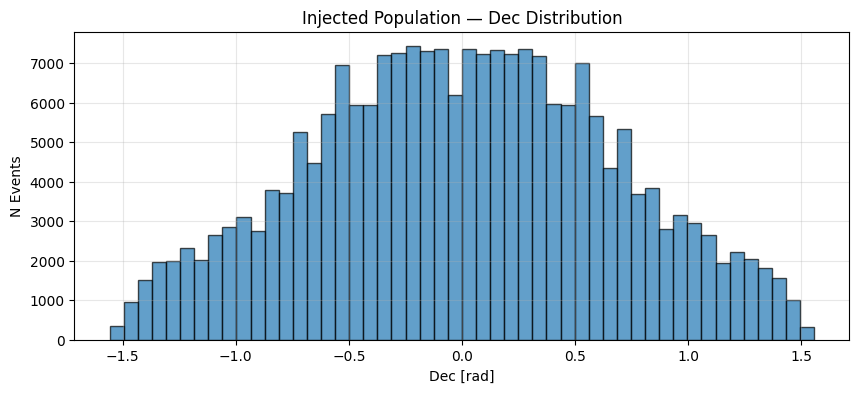

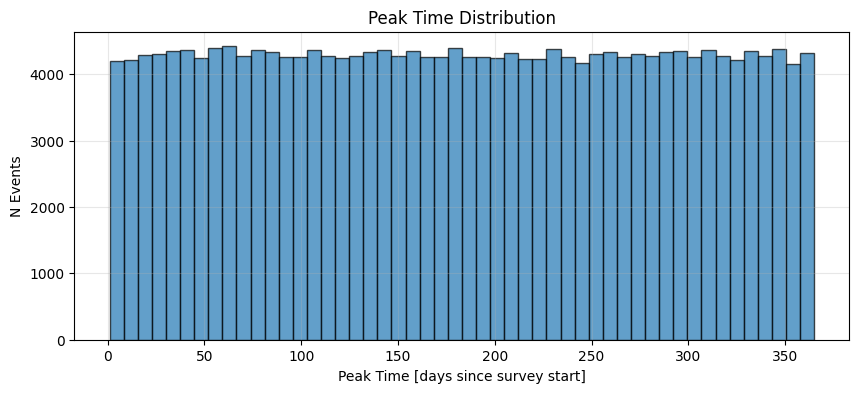

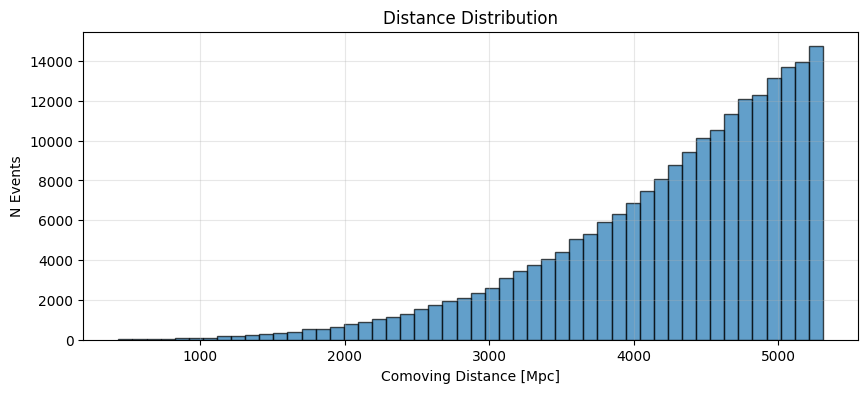

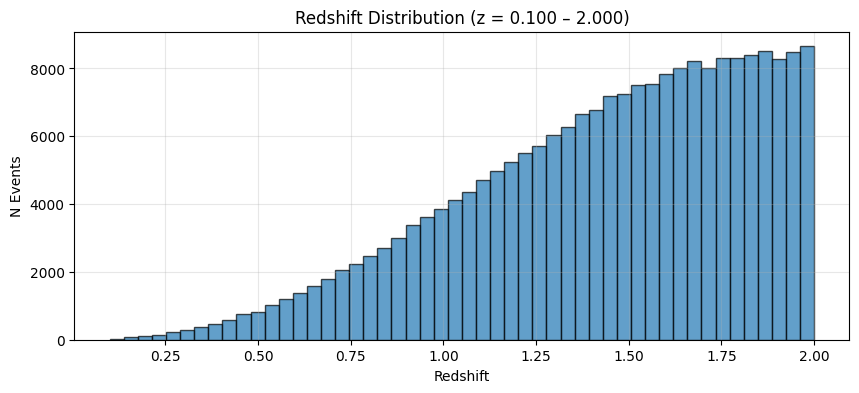

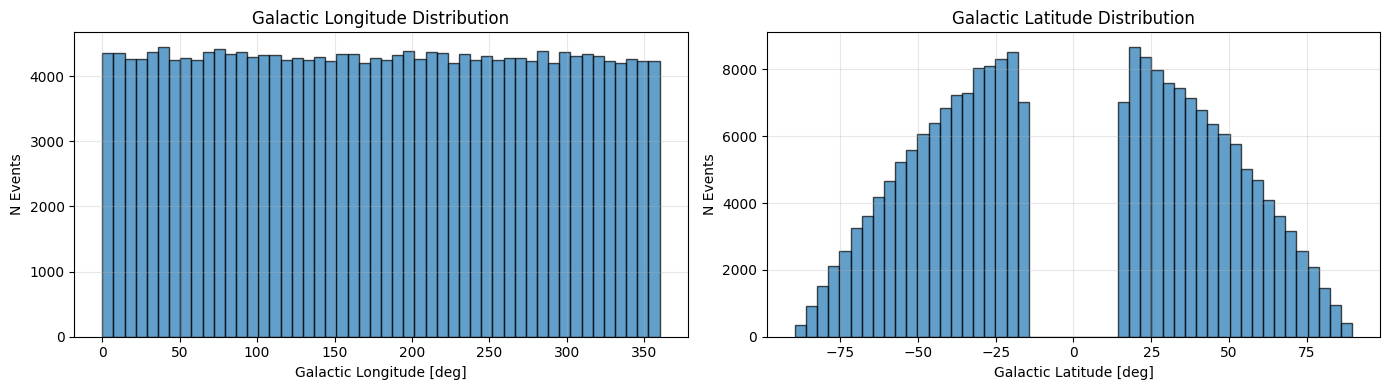

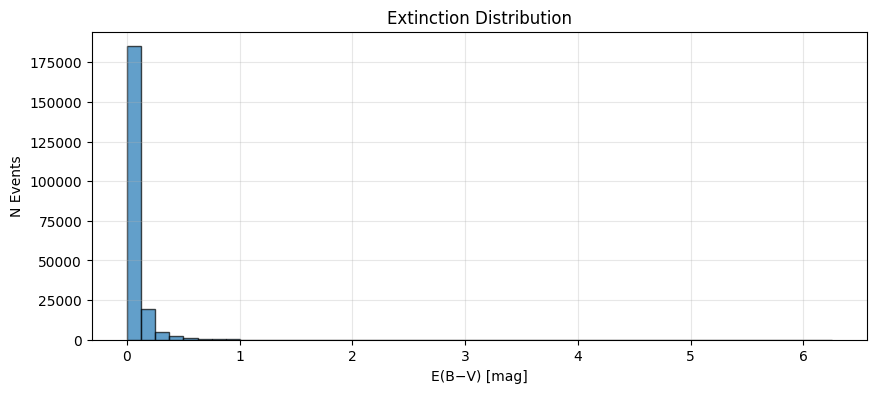

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl

✓ Generated 214954 SLSNe

Running cadence: baseline_v4.3.1_10yrs

Results for baseline_v4.3.1_10yrs:
  Events simulated: 214954
  Events detected:  1014 (0.5%)
  Avg filters/detection: 0.0
  Avg observations/detection: 0.0
  Saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/slsn_detect_baseline_v4.3.1_10yrs.csv
  Saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/local_efficiency_baseline_v4.3.1_10yrs.csv
Filter testing.....
   Generating diagnostic plots...
[diag] using band for injected/observed panels: r


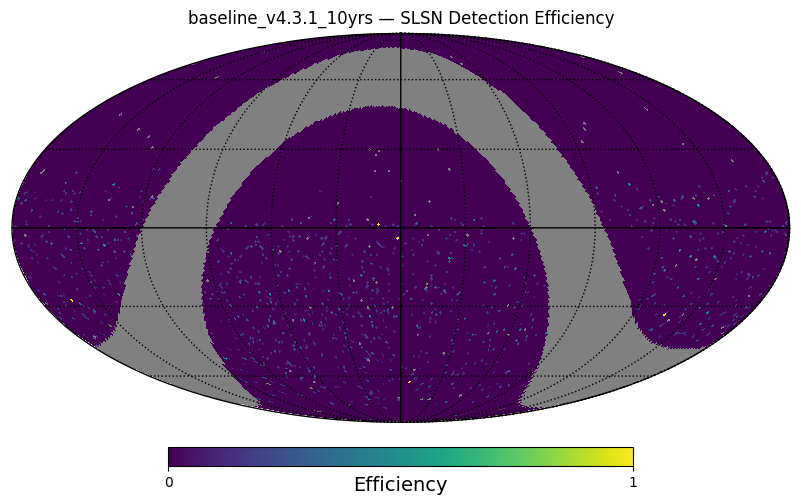

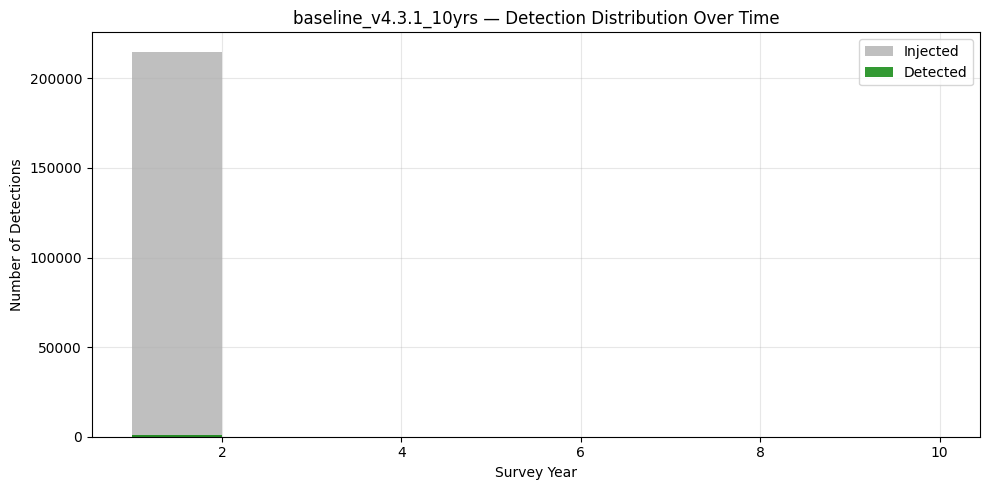

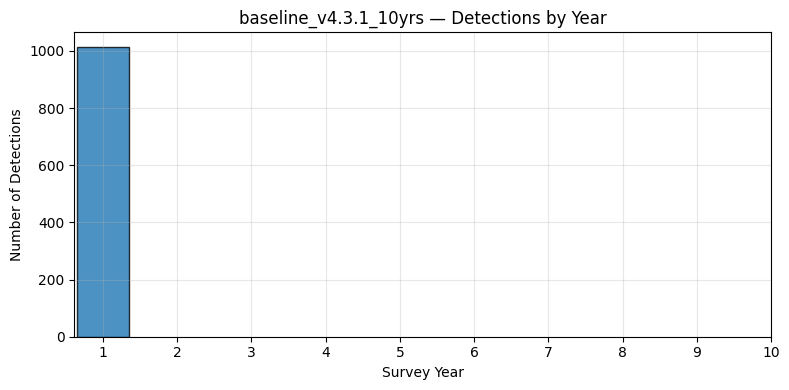

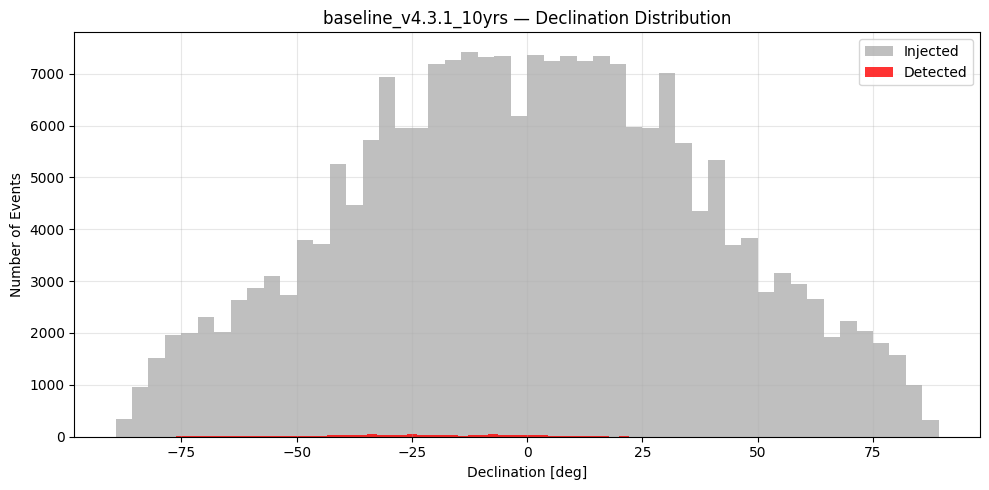

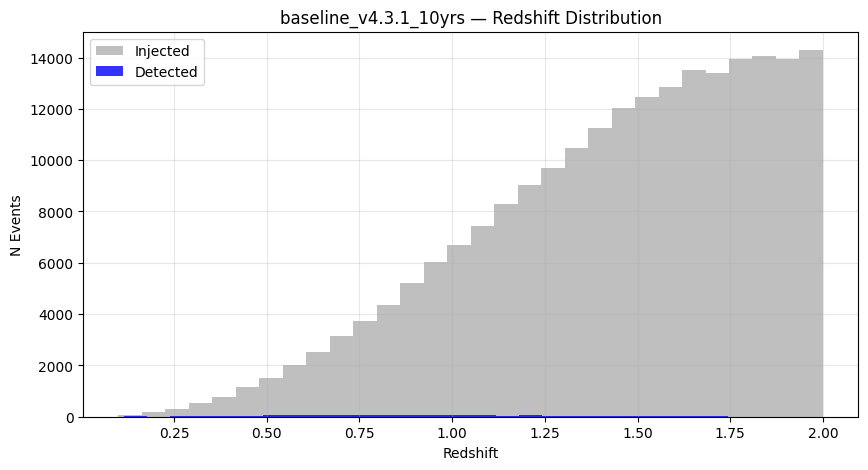

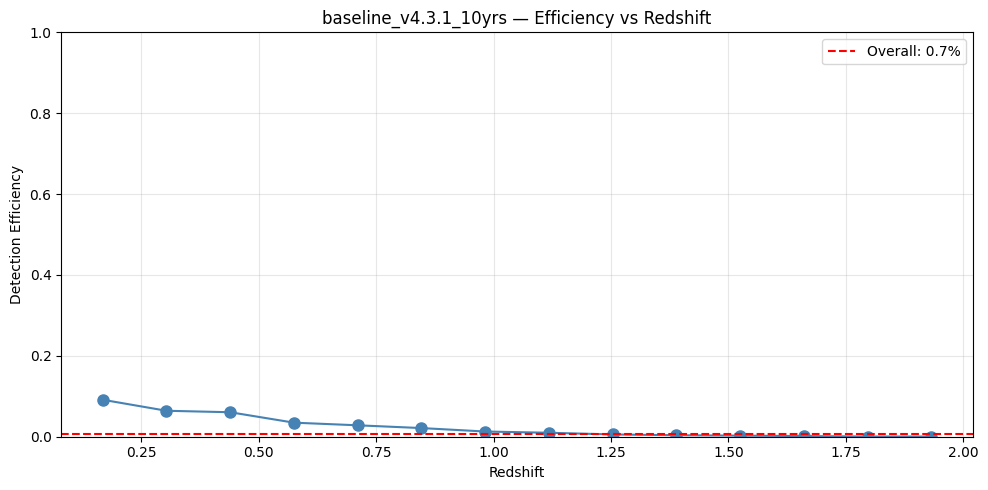

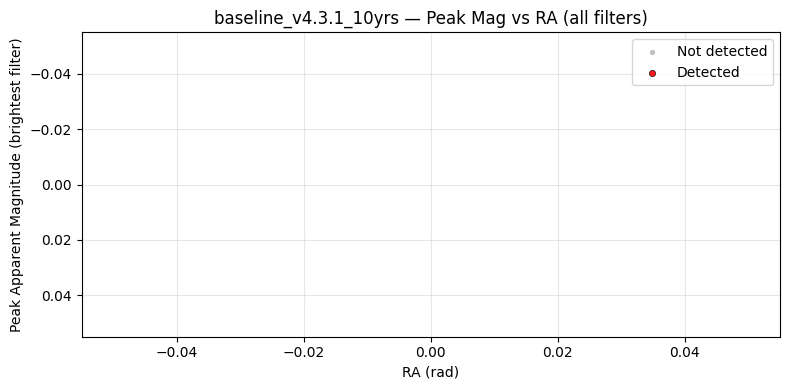

[diag] Using minimum magnitude across all filters for each event


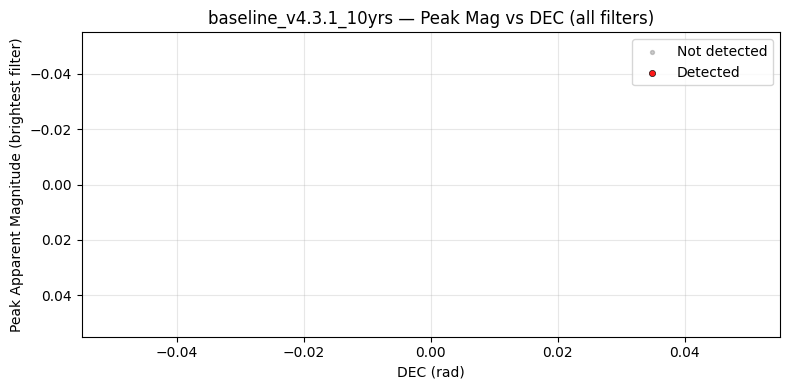

[diag] finite first_det_mjd: 0
[diag] per_filter_min_mag present: True
[diag] finite observed-peak (r): 0
[diag] finite injected-peak (r): 0
   Saved diagnostic plots
[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/Metric_temp_baseline_v4.3.1_10yrs

✓ Detection efficiency: 0.7%


In [226]:
# ============================================================================
# CELL 11: Run detection metrics (uses stable modules, no changes)
# ============================================================================

cadences = ['baseline_v4.3.1_10yrs']
db_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
output_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving")

# ============================================================================
# CELL 7: Generate population WITH rate evolution
# ============================================================================

pop_evolving = generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model=templates,
    rate_model='evolving',      # KEY: Use rate evolution!
    R_ref=1e-7,                  # Quimby+13 @ z=0.17
    z_ref=0.17,
    OH_max=8.3,                  # Schulze+21 threshold
    z_min=0.1,
    z_max=2.0,
    t_start=1,
    t_end=365,
    gal_lat_cut=15.0,            # Optional: avoid Galactic plane
    seed=42,
    save_to=Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl"),
    make_debug_plots=True
)

print(f"\n✓ Generated {len(pop_evolving.slice_points['sid'])} SLSNe")


# This uses the UNCHANGED run_slsn_detect from runners.py
results_evolving, metric = run_slsn_detect(
    templates=templates,
    population=pop_evolving,
    cadences=cadences,
    db_dir=db_dir,
    output_dir=output_dir,
    store_obs_mode="meta",
    make_plots=True,
    save_csv=True
)

print(f"\n✓ Detection efficiency: {results_evolving[cadences[0]]['detected'].mean():.1%}")


Running All Three SLSN Metrics on Evolving Population
Population: 214,954 events
Rate model: evolving (R_ref=1e-7, z_ref=0.17, OH_max=8.3)
Cadences: ['baseline_v4.3.1_10yrs']


Running cadence: baseline_v4.3.1_10yrs
  Running SLSN_Detect_Metric...
    Efficiency: 0.5% (1014/214954)


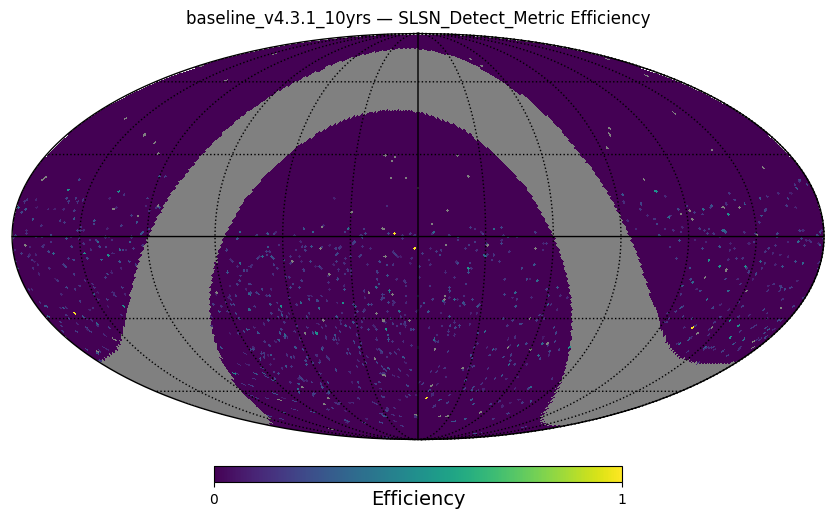

  Running SLSN_CharacterizeMetric...
    Efficiency: 0.1% (297/214954)


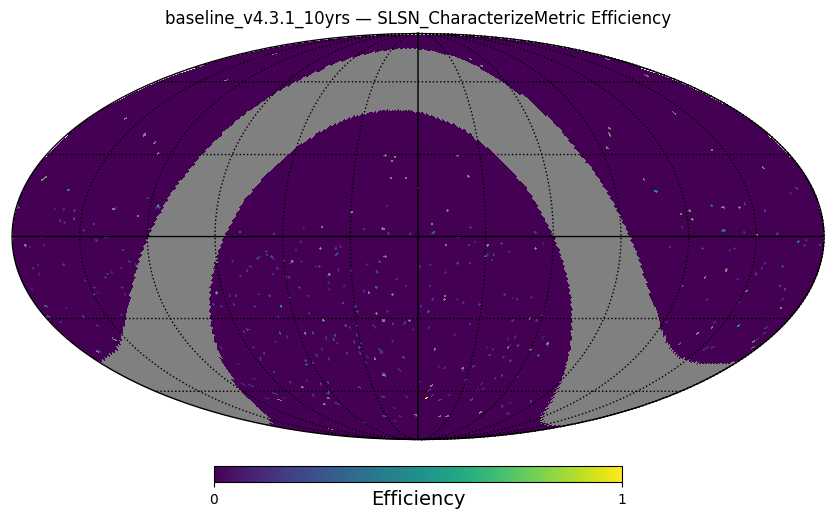

  Running SLSN_SpecTriggerMetric...
    Efficiency: 0.0% (39/214954)


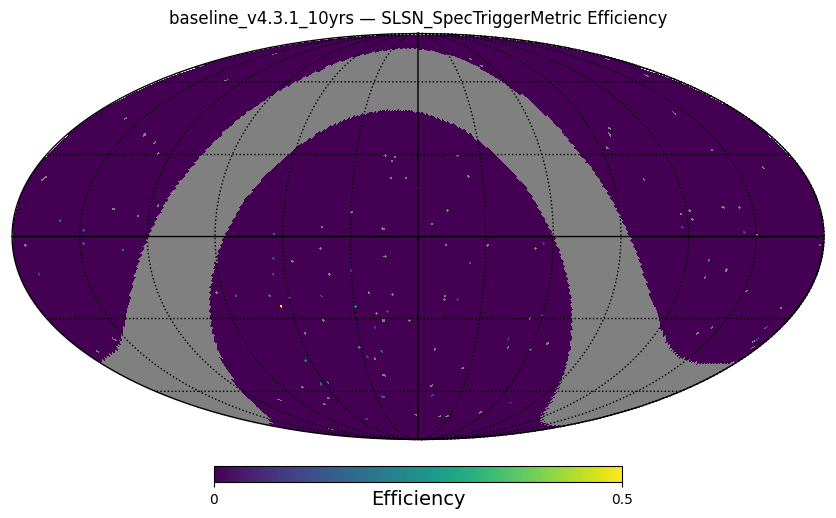


Summary saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving_multimet/slsn_multi_metrics_summary.csv

RESULTS: All Three Metrics (Evolving Rate Model)
              cadence                  metric  n_events  n_success  efficiency
baseline_v4.3.1_10yrs      SLSN_Detect_Metric    214954       1014    0.004717
baseline_v4.3.1_10yrs SLSN_CharacterizeMetric    214954        297    0.001382
baseline_v4.3.1_10yrs  SLSN_SpecTriggerMetric    214954         39    0.000181

✓ Summary saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving_multimet/evolving_rate_all_metrics_summary.csv

KEY FINDINGS
SLSN_Detect_Metric           0.5%  (  1,014 / 214,954)
SLSN_CharacterizeMetric      0.1%  (    297 / 214,954)
SLSN_SpecTriggerMetric       0.0%  (     39 / 214,954)



In [233]:
# ============================================================================
# CELL 12: Run All Three Metrics on Evolving Population
# ============================================================================

import os
from pathlib import Path
from slsn_metrics.metrics import (
    SLSN_Detect_Metric, 
    SLSN_CharacterizeMetric, 
    SLSN_SpecTriggerMetric
)
from slsn_metrics.runners import run_slsn_multi_metrics

# Setup paths
cadences = ['baseline_v4.3.1_10yrs']
db_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
output_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving_multimet")
output_dir.mkdir(parents=True, exist_ok=True)

mjd0 = 60980.5
ignore_triples = True

print("\n" + "="*70)
print("Running All Three SLSN Metrics on Evolving Population")
print("="*70)
print(f"Population: {len(pop_evolving.slice_points['sid']):,} events")
print(f"Rate model: evolving (R_ref=1e-7, z_ref=0.17, OH_max=8.3)")
print(f"Cadences: {cadences}")
print("="*70 + "\n")

# Create all three metrics
metrics_list = [
    SLSN_Detect_Metric(
        lc_model=templates, 
        mjd0=mjd0, 
        store_obs_mode="meta"  # Use "meta" if you want obs records
    ),
    SLSN_CharacterizeMetric(
        lc_model=templates, 
        mjd0=mjd0, 
        store_obs_mode="meta"
    ),
    SLSN_SpecTriggerMetric(
        lc_model=templates, 
        mjd0=mjd0, 
        store_obs_mode="meta"
    )
]

# Run all metrics
summary_df = run_slsn_multi_metrics(
    templates=templates,
    population=pop_evolving,  # ← YOUR NEW EVOLVING POPULATION!
    cadences=cadences,
    db_dir=str(db_dir),
    output_dir=str(output_dir),
    metrics_list=metrics_list,
    mjd0=mjd0,
    ignore_triples=ignore_triples,
    save_summary=True,
    make_plots=True,  # HEALPix efficiency maps
    verbose=True
)

# Display results
print("\n" + "="*70)
print("RESULTS: All Three Metrics (Evolving Rate Model)")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save summary
summary_path = output_dir / "evolving_rate_all_metrics_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\n✓ Summary saved to {summary_path}")

# Print key findings
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
for _, row in summary_df.iterrows():
    print(f"{row['metric']:<25} {row['efficiency']*100:>6.1f}%  ({row['n_success']:>7,} / {row['n_events']:>7,})")
print("="*70 + "\n")

In [ ]:
# ============================================================================
# CELL 12: Sensitivity analysis - vary metallicity threshold
# ============================================================================

OH_values = [8.2, 8.3, 8.4]  # ±0.1 dex around Schulze+21

for OH_max in OH_values:
    print(f"\n{'='*70}")
    print(f"Testing OH_max = {OH_max}")
    print(f"{'='*70}")
    
    pop_test = generate_SLSN_PopSlicer_with_rate_evolution(
        lc_model=templates,
        rate_model='evolving',
        R_ref=1e-7,
        z_ref=0.17,
        OH_max=OH_max,
        z_min=0.1,
        z_max=2.0,
        make_debug_plots=False,
        save_to=Path(f"output/SLSNe/pop_OH{OH_max:.1f}.pkl")
    )
    
    df = compare_simulated_vs_observed_rates(pop_test)